В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import statsmodels.api as sm


# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [4]:
cars_df = pd.read_csv('cars.csv')
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [8]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [13]:
cars_df.Brand.unique()


array(['Toyota', 'Honda', 'Ford', 'Maruti', 'Hyundai', 'Tata', 'Mahindra',
       'Volkswagen', 'Audi', 'BMW', 'Mercedes'], dtype=object)

In [15]:
cars_df.Model.nunique()

58

In [16]:
cars_df.Year.unique()

array([2018, 2019, 2017, 2020, 2016, 2021])

In [19]:
cars_df.Kilometers_Driven.unique()

array([50000, 40000, 20000, 30000, 60000, 35000, 45000, 25000, 28000,
       22000, 18000, 42000, 32000, 38000, 24000, 26000, 15000, 10000])

In [20]:
cars_df.Fuel_Type.unique()

array(['Petrol', 'Diesel'], dtype=object)

In [23]:
cars_df.Transmission.unique()


array(['Manual', 'Automatic'], dtype=object)

In [24]:
cars_df.Owner_Type.unique()

array(['First', 'Second', 'Third'], dtype=object)

In [27]:
cars_df.Mileage.unique()

array([15, 17, 10, 23, 18, 20, 16, 12, 19, 25, 13, 24, 22, 14, 21])

In [28]:
cars_df.Engine.unique()

array([1498, 1597, 4951, 1248, 1999, 1198, 2179,  999, 1968, 1995, 1991,
       2198, 1497, 1956, 1462, 1395, 2755, 1194, 1582, 1199, 2184, 1984,
       1950, 1197, 2993, 2996, 1496, 1086, 1047, 2967, 2998, 2143, 2487,
       2261, 1598, 1998])

In [29]:
cars_df.Power.unique()

array([108, 140, 395,  74, 194,  76, 187, 190, 181, 158, 113, 167, 103,
        98, 141, 148, 241, 171,  94, 126,  85, 130, 174, 191, 150, 261,
       362, 106,  68,  69, 245, 335, 170, 176, 396,  81,  84, 115, 258,
       121])

In [30]:
cars_df.Seats.unique()

array([5, 4, 7])

In [31]:
cars_df.Price.unique()

array([ 800000, 1000000, 2500000,  600000,  850000,  750000,  900000,
        650000, 2200000, 2700000, 2300000, 2000000, 1600000, 1800000,
       1900000, 3000000, 1400000,  550000, 1200000, 3200000, 2800000,
       1300000,  700000,  500000, 3500000, 4000000, 1500000,  450000,
       2400000, 2600000, 2900000])

In [33]:
cars_df.Car_ID.nunique()

100

В наборі даних 8 числових і 5 категоріальних колонок з них:
- 1 колонка з унікальними значеннями (Car_ID)
- 2 бінарні (Fuel_Type, Transmission)
- 2 колонки з трьома значеннями (Owner, Seats)
- 3 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 5 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)

З приводу колонки Year я сумніваюся, чи вона має порядок чи ні, там всього 6 років, можна і розбити на значення по новизні.

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [37]:
X = cars_df.drop('Price', axis=1) 
y = cars_df['Price']  

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [45]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 83 to 75
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             80 non-null     int64 
 1   Brand              80 non-null     object
 2   Model              80 non-null     object
 3   Year               80 non-null     int64 
 4   Kilometers_Driven  80 non-null     int64 
 5   Fuel_Type          80 non-null     object
 6   Transmission       80 non-null     object
 7   Owner_Type         80 non-null     object
 8   Mileage            80 non-null     int64 
 9   Engine             80 non-null     int64 
 10  Power              80 non-null     int64 
 11  Seats              80 non-null     int64 
dtypes: int64(7), object(5)
memory usage: 8.1+ KB


**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [47]:
cars_df.Fuel_Type.describe()

count        100
unique         2
top       Petrol
freq          52
Name: Fuel_Type, dtype: object

In [49]:
cars_df.Fuel_Type.value_counts()

Fuel_Type
Petrol    52
Diesel    48
Name: count, dtype: int64

In [ ]:
smoker_codes = {'no': 0, 'yes': 1}
medical_df['smoker_code'] = medical_df.smoker.map(smoker_codes)

In [50]:
cars_fuel_type = {'Diesel': 0, 'Petrol': 1}
cars_df['cars_fuel_type'] = cars_df.Fuel_Type.map(cars_fuel_type)

In [51]:
cars_df.cars_fuel_type.value_counts()

cars_fuel_type
1    52
0    48
Name: count, dtype: int64

In [52]:
cars_df.Transmission.value_counts()

Transmission
Automatic    57
Manual       43
Name: count, dtype: int64

In [53]:
cars_transmission = {'Manual': 0, 'Automatic': 1}
cars_df['cars_transmission'] = cars_df.Transmission.map(cars_transmission)

In [54]:
cars_df.cars_transmission.value_counts()

cars_transmission
1    57
0    43
Name: count, dtype: int64

In [56]:
brand_enc = preprocessing.OneHotEncoder(handle_unknown="ignore")
brand_enc.fit(X_train[['Brand']])
brand_enc.categories_

[array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
        'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)]

In [57]:
brand_train_ohe = brand_enc.transform(X_train[['Brand']]).toarray()
brand_test_ohe  = brand_enc.transform(X_test[['Brand']]).toarray()

In [59]:
cols = brand_enc.categories_[0] 

X_train[cols] = brand_train_ohe
X_test[cols]  = brand_test_ohe

In [60]:
X_train.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,...,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [61]:
X_test.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,...,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [63]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [64]:
X_train_num = X_train.select_dtypes(include='number')

In [65]:
train_num_with_target = pd.concat([X_train_num, y_train], axis=1)

In [66]:
corr_matrix = train_num_with_target.corr()
corr_matrix

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Price
Car_ID,1.000000,0.137027,-0.356614,0.100891,-0.089284,-0.006319,-0.063793,0.089473,0.048335,-0.020240,-0.050809,0.016831,0.006797,-0.054463,-0.045431,-0.032926,0.011350,0.020129,0.038923,0.025560
Year,0.137027,1.000000,-0.708525,0.278559,-0.392764,-0.248442,-0.278755,-0.256523,0.202517,-0.150454,-0.037437,-0.092099,0.181669,0.285094,-0.115157,0.248715,-0.219346,0.018255,-0.014499,-0.233769
Kilometers_Driven,-0.356614,-0.708525,1.000000,-0.126621,0.101219,-0.060803,0.403656,0.095879,-0.247042,-0.009761,0.057372,0.154362,-0.040344,-0.190420,-0.091731,0.030399,0.368519,-0.137675,-0.001772,-0.083951
Mileage,0.100891,0.278559,-0.126621,1.000000,-0.710516,-0.684705,-0.178619,-0.152701,-0.134105,-0.296480,0.358630,0.217406,0.029427,0.116389,-0.238489,0.347678,-0.201565,0.085114,0.026624,-0.638404
Engine,-0.089284,-0.392764,0.101219,-0.710516,1.000000,0.801638,0.167326,0.085153,0.287119,0.184231,-0.154491,-0.182213,-0.024973,-0.193257,0.163871,-0.340051,0.234889,-0.165115,-0.196106,0.710561
Power,-0.006319,-0.248442,-0.060803,-0.684705,0.801638,1.000000,-0.139388,0.157050,0.372652,0.240501,-0.191810,-0.170966,-0.118021,-0.220984,0.280827,-0.316989,-0.040478,-0.148437,-0.204309,0.849137
Seats,-0.063793,-0.278755,0.403656,-0.178619,0.167326,-0.139388,1.000000,0.123674,-0.108079,-0.161451,0.200303,-0.086439,0.007738,-0.078379,-0.108079,-0.012748,0.348535,-0.094002,-0.043849,0.000979
Audi,0.089473,-0.256523,0.095879,-0.152701,0.085153,0.157050,0.123674,1.000000,-0.118678,-0.118678,-0.086066,-0.094916,-0.076472,-0.086066,-0.118678,-0.125988,-0.111111,-0.103221,-0.203925,0.328858
BMW,0.048335,0.202517,-0.247042,-0.134105,0.287119,0.372652,-0.108079,-0.118678,1.000000,-0.126761,-0.091928,-0.101380,-0.081680,-0.091928,-0.126761,-0.134568,-0.118678,-0.110250,0.009076,0.477522
Ford,-0.020240,-0.150454,-0.009761,-0.296480,0.184231,0.240501,-0.161451,-0.118678,-0.126761,1.000000,-0.091928,-0.101380,-0.081680,-0.091928,-0.126761,-0.134568,-0.118678,-0.110250,0.190586,-0.004592


In [67]:
corr_with_price = corr_matrix['Price'].sort_values(ascending=False)
corr_with_price

Price                1.000000
Power                0.849137
Engine               0.710561
BMW                  0.477522
Mercedes             0.431606
Audi                 0.328858
Car_ID               0.025560
Seats                0.000979
Ford                -0.004592
Toyota              -0.023778
Kilometers_Driven   -0.083951
Volkswagen          -0.158742
Mahindra            -0.178627
Honda               -0.209779
Year                -0.233769
Maruti              -0.249737
Hyundai             -0.263022
Owner_Type_Codes    -0.265537
Tata                -0.341815
Mileage             -0.638404
Name: Price, dtype: float64

In [68]:
strong_corr = corr_with_price[abs(corr_with_price) > 0.5]
strong_corr

Price      1.000000
Power      0.849137
Engine     0.710561
Mileage   -0.638404
Name: Price, dtype: float64

Найбільше на ціну впливає Power, Engine, Mileage. Із брендів автомобілів, найбільше корелюється BMW, Mercedes. Тобто найбільше впливають на ціну технічні характеристики машини

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [69]:
X_test_num = X_test.select_dtypes(include='number')

In [73]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_num, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [74]:
y_train_pred = lin_reg.predict(X_train_num)
y_test_pred = lin_reg.predict(X_test_num)

In [75]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("RMSE train:", rmse_train)
print("RMSE test:", rmse_test)

RMSE train: 252657.27724736556
RMSE test: 248249.6136145391


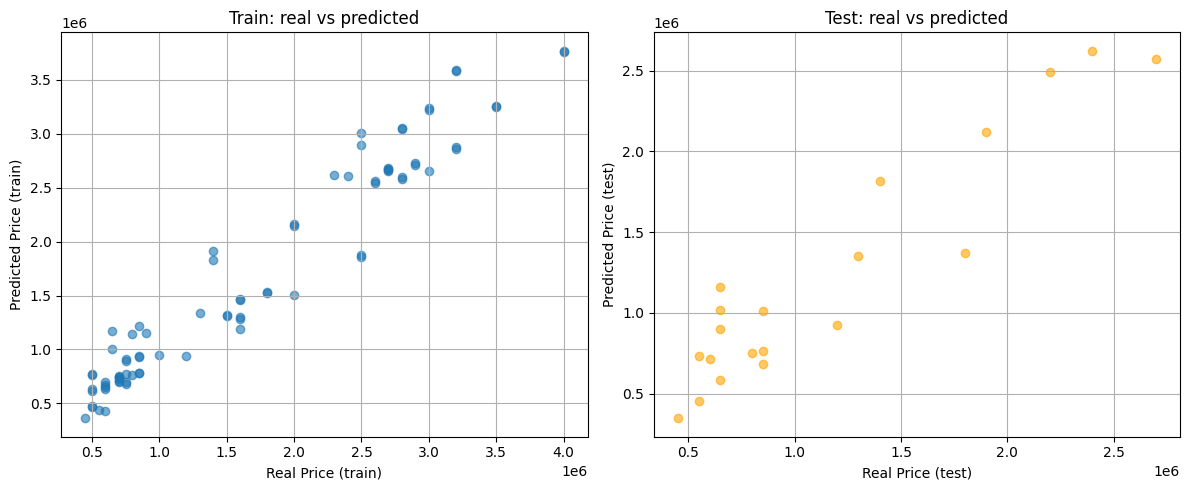

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_train, y_train_pred, alpha=0.6)
plt.xlabel("Real Price (train)")
plt.ylabel("Predicted Price (train)")
plt.title("Train: real vs predicted")
plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(y_test, y_test_pred, alpha=0.6, color='orange')
plt.xlabel("Real Price (test)")
plt.ylabel("Predicted Price (test)")
plt.title("Test: real vs predicted")
plt.grid(True)

plt.tight_layout()
plt.show()

Значення RMSE на тренувальній та тестовій вибірках є майже однаковими, що свідчить про відсутність перенавчання та хорошу здатність моделі до узагальнення.
Загалом можель виглядає добре, на тестовому наборі майже збігається уявна лінія розташування точок. Трохи невистачає точок на тестових даних в проміжку від 2.5, але загалом непогано

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [80]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

In [81]:
lin_reg_scaled = LinearRegression().fit(X_train_scaled, y_train)

In [82]:
coefs = pd.Series(lin_reg_scaled.coef_, index=X_train_num.columns).sort_values(ascending=False)
coefs

Power                460238.563128
Mercedes             267134.605117
BMW                  263621.151556
Audi                 219326.973011
Engine                94812.492973
Seats                 77048.459247
Year                  29646.157096
Car_ID                10391.901257
Kilometers_Driven      6270.745117
Mileage              -28338.022658
Volkswagen           -49009.222227
Owner_Type_Codes     -49458.187600
Toyota               -49885.435459
Ford                 -99983.523443
Maruti              -115590.838380
Honda               -117427.497575
Mahindra            -123408.855189
Hyundai             -134316.487395
Tata                -164553.287214
dtype: float64

На маштабованих даних коефіцієнти вже показують вплив на ціну значення Power та сегменту преміальних брендів машин.Трохи дивно, що інщі теїнічні їарактеристики не так чильно впливають, як от рік та кілометраж

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [84]:
Y = y_train
X = pd.DataFrame(X_train_scaled, columns=X_train_num.columns, index=X_train_num.index)

X = sm.add_constant(X)        
model = sm.OLS(Y, X)           
results = model.fit()           
print(results.summary())  

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     53.36
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           1.60e-30
Time:                        13:25:20   Log-Likelihood:                -1108.7
No. Observations:                  80   AIC:                             2255.
Df Residuals:                      61   BIC:                             2301.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   3.23e+0

Статистично значущі ознаки (p < 0.05): Power — єдина числова технічна характеристика, яка залишилась значущою. Крім того, Brand впливає також Audi, BMW, Ford, Honda, Hyundai, Mahindra, Maruti, Mercedes, Tata

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [86]:
significant_features = [
    'Power',
    'Audi', 'BMW', 'Ford', 'Honda', 'Hyundai',
    'Mahindra', 'Maruti', 'Mercedes', 'Tata'
]

In [87]:
Y = y_train
X = pd.DataFrame(
    X_train_scaled,
    columns=X_train_num.columns,
    index=X_train_num.index
)

X = X[significant_features]
X = sm.add_constant(X)

model = sm.OLS(Y, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     87.23
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           4.08e-35
Time:                        13:34:45   Log-Likelihood:                -1116.9
No. Observations:                  80   AIC:                             2256.
Df Residuals:                      69   BIC:                             2282.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.68e+06   3.37e+04     49.854      0.0

Повна модель:
	•	R² = 0.940
	•	Adj. R² = 0.923
	•	Кількість ознак: 18

Модель тільки зі стат. значущими ознаками:
	•	R² = 0.927
	•	Adj. R² = 0.916
	•	Кількість ознак: 10

Ззначних змін немає
	•	R² зменшився лише на 0.013
	•	Adj. R² зменшився лише на 0.007

Це дуже невелика різниця, враховуючи, що кількість змінних зменшилась майже вдвічі

Отже, ознаки, які не були враховані, не давали суттєвого додаткового пояснення.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [88]:
features_relaxed = [
    'Power', 'Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 
    'Mahindra', 'Maruti', 'Mercedes', 'Tata',
    'Seats', 'Engine', 'Toyota', 'Volkswagen'
]

Y = y_train
X = pd.DataFrame(X_train_scaled, columns=X_train_num.columns, index=X_train_num.index)
X = X[features_relaxed]
X = sm.add_constant(X)

model = sm.OLS(Y, X)
results_relaxed = model.fit()

print(results_relaxed.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                     77.35
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           1.05e-34
Time:                        13:50:30   Log-Likelihood:                -1109.9
No. Observations:                  80   AIC:                             2248.
Df Residuals:                      66   BIC:                             2281.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.68e+06   3.16e+04     53.191      0.0


* R2 зрос з 0.927 до 0.938.** Це означає, що Модель 3 пояснює на 1.1% більше варіації залежної змінної, ніж попередня скорочена модель.
* **Adj.  зрос з 0.916 до 0.926.** Це найважливіший сигнал. Оскільки скоригований коефіцієнт детермінації зріс, це підтверджує, що додані або змінені ознаки дійсно корисні, а не просто створюють "шум".

Модель 3 майже наздогнала повну модель за  (0.938 проти 0.940), але перегнала її за Adj. (0.926 проти 0.923). Це свідчить про те, що повна модель була переобтяжена зайвими параметрами, які лише заважали точності прогнозу.


Яку модель обрати для використання?

Я б залишила Модель 3. Найвищий Adj.  (0.926):** Серед усіх трьох варіантів ця модель має найкращу здатність до узагальнення. Вона демонструє найвищу точність з урахуванням кількості ознак. Отримуємо майже ту саму точність, що й у повної моделі, але з меншою кількістю змінних.
